In [1]:
import numpy as np
import keras
import keras.backend as K
from keras.layers import Input, Dense, Activation, LeakyReLU, BatchNormalization
from keras.models import Sequential
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
import tensorflow.keras as tk
mnist = tk.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

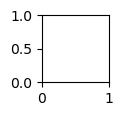

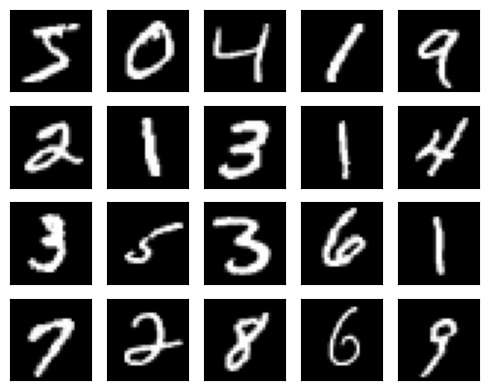

In [4]:
plt.figure(figsize=(5, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


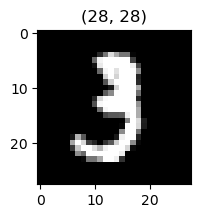

In [5]:
# x_train.min(), x_train.max()

sample = x_train[10]

plt.figure(figsize=(3, 2))
plt.title(sample.shape)
plt.imshow(sample, cmap='gray')
plt.show()


In [6]:
def make_latent_samples(n_samples, sample_size):
    #return np.random.uniform(-1, 1, size=(n_samples, sample_size))
    return np.random.normal(loc=0, scale=1, size=(n_samples, sample_size))

#The sample size is a hyperparameter. Below, we use a vector of 100 randomly generated number as a sample.
make_latent_samples(1, 100) # generates one sample


array([[-1.97924828e+00,  6.43251533e-01,  1.10913464e+00,
         8.88611015e-01,  7.40667929e-01, -3.84120371e-01,
         2.14285762e-01,  6.61444194e-02, -1.07854532e+00,
         4.31641150e-01, -3.54271231e-01,  1.02740672e+00,
         1.08226864e+00,  4.27646107e-01,  7.13185214e-01,
         1.06864271e+00,  5.85893960e-01, -8.38157600e-02,
        -1.28150006e+00,  2.03587741e-01, -1.09772942e+00,
        -9.86500102e-01,  8.35536153e-02, -1.94037763e-01,
         1.40500751e+00,  2.30550863e+00,  2.07970534e-01,
        -5.19562421e-01,  1.85699404e+00,  7.28650844e-01,
        -1.03747251e-01, -4.68806413e-01,  1.75779257e+00,
        -4.60032513e-02, -5.26350191e-02, -4.61663509e-02,
        -1.77053662e+00, -2.24882171e-01, -6.58811989e-01,
         2.36671568e-01, -2.99891740e-01,  8.49440661e-02,
         1.68329365e+00, -1.29909965e+00, -2.47553213e-01,
        -1.42403771e+00, -1.57541806e+00, -2.15336935e+00,
        -1.09228699e+00, -1.37570402e+00, -9.34376082e-0

In [7]:
generator = Sequential([
    Dense(128, input_shape=(100,)),
    LeakyReLU(alpha=0.01),
    Dense(784),
    Activation('tanh')
], name='generator')

generator.summary()


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 784)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,064 (445.56 KB)

 Trainable params: 114,064 (445.56 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
discriminator = Sequential([
    Dense(128, input_shape=(784,)),
    LeakyReLU(alpha=0.01),
    Dense(1),
    Activation('sigmoid')
], name='discriminator')

discriminator.summary()


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# maintain the same shared weights with the generator and the discriminator.
gan = Sequential([
    generator,
    discriminator
])

gan.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ generator (Sequential)          │ (None, 784)            │       114,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator (Sequential)      │ (None, 1)              │       100,609 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,673 (838.57 KB)

 Trainable params: 214,673 (838.57 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
def make_trainable(model, trainable):
    for layer in model.layers:
        layer.trainable = trainable
make_trainable(discriminator, False)
discriminator.summary()


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 100,609 (393.00 KB)

In [12]:
def make_simple_GAN(sample_size, g_hidden_size, d_hidden_size, leaky_alpha, g_learning_rate, d_learning_rate):
    K.clear_session()
    
    generator = Sequential([
        Dense(g_hidden_size, input_shape=(sample_size,)),
        LeakyReLU(alpha=leaky_alpha),
        Dense(784),        
        Activation('tanh')
    ], name='generator')    
    discriminator = Sequential([
        Dense(d_hidden_size, input_shape=(784,)),
        LeakyReLU(alpha=leaky_alpha),
        Dense(1),
        Activation('sigmoid')
    ], name='discriminator')    
    gan = Sequential([
        generator,
        discriminator
    ])
    discriminator.compile(optimizer=Adam(lr=d_learning_rate), loss='binary_crossentropy')
    gan.compile(optimizer=Adam(lr=g_learning_rate), loss='binary_crossentropy')
    
    return gan, generator, discriminator


In [13]:
def preprocess(x):    
    x = x.reshape(-1, 784) # 784=28*28
    x = np.float64(x)
    x = (x / 255 - 0.5) * 2
    x = np.clip(x, -1, 1)
    return x

X_train_real = preprocess(x_train)
X_test_real  = preprocess(x_test)


In [14]:
def deprocess(x):
    x = (x / 2 + 1) * 255
    x = np.clip(x, 0, 255)
    x = np.uint8(x)
    x = x.reshape(28, 28)
    return x


In [15]:
def make_labels(size):
    return np.ones([size, 1]), np.zeros([size, 1])

y_real_10, y_fake_10 = make_labels(10)

y_real_10, y_fake_10


(array([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]]))

In [20]:
# hyperparameters
sample_size     = 100
g_hidden_size   = 128
d_hidden_size   = 128
leaky_alpha     = 0.01
g_learning_rate = 0.0001
d_learning_rate = 0.001
epochs          = 100
batch_size      = 64
eval_size       = 16

from tensorflow.keras.optimizers import Adam

def make_simple_GAN(sample_size,
                    g_hidden_size,
                    d_hidden_size,
                    leaky_alpha,
                    g_learning_rate,
                    d_learning_rate):

    generator = build_generator(sample_size, g_hidden_size)
    discriminator = build_discriminator(d_hidden_size, leaky_alpha)

    discriminator.compile(
        optimizer=Adam(learning_rate=d_learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    discriminator.trainable = False

    gan_input = Input(shape=(sample_size,))
    fake_image = generator(gan_input)
    gan_output = discriminator(fake_image)

    gan = Model(gan_input, gan_output)

    gan.compile(
        optimizer=Adam(learning_rate=g_learning_rate),
        loss="binary_crossentropy"
    )

    return gan, generator, discriminator

In [ ]:
losses = []

for e in range(epochs):

    for i in range(len(X_train_real)//batch_size):

        X_batch_real = X_train_real[i*batch_size:(i+1)*batch_size]

        latent_samples = make_latent_samples(batch_size, sample_size)
        X_batch_fake = generator.predict_on_batch(latent_samples)

        make_trainable(discriminator, True)

        discriminator.train_on_batch(
            X_batch_real,
            y_train_real * (1 - smooth)
        )

        discriminator.train_on_batch(
            X_batch_fake,
            y_train_fake
        )

        make_trainable(discriminator, False)

        gan.train_on_batch(
            latent_samples,
            y_train_real
        )

    X_eval_real = X_test_real[
        np.random.choice(len(X_test_real), eval_size, replace=False)
    ]

    latent_samples = make_latent_samples(eval_size, sample_size)

    X_eval_fake = generator.predict_on_batch(latent_samples)

    d_loss  = discriminator.test_on_batch(X_eval_real, y_eval_real)
    d_loss += discriminator.test_on_batch(X_eval_fake, y_eval_fake)

    g_loss  = gan.test_on_batch(latent_samples, y_eval_real)

    losses.append((d_loss, g_loss))

    print("Epoch: {:>3}/{} Discriminator Loss: {:>6.4f} Generator Loss: {:>6.4f}".format(
        e+1, epochs, d_loss, g_loss))

ValueError: You must call `compile()` before using the model.

In [ ]:
losses = np.array(losses)

fig, ax = plt.subplots()
plt.plot(losses.T[0], label='Discriminator')
plt.plot(losses.T[1], label='Generator')
plt.title("Training Losses")
plt.legend()
plt.show()


In [ ]:
latent_samples = make_latent_samples(20, sample_size)
generated_digits = generator.predict(latent_samples)

plt.figure(figsize=(10, 8))
for i in range(20):
    img = deprocess(generated_digits[i])
    plt.subplot(4, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()
